### Modelo CNN capaz de classficar filtros gaussianos com diferentes larguras

In [1]:
# importações
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# infos sobre modelos
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

### Criando os Gaussian Blurs com larguras diferentes

In [3]:
nPerClass = 1000
imgSize = 91

x = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)

# larguras (sigma)
widths = [1.8,2.4]

# Inicializando os tensores com imagens e rótulos
images = torch.zeros(2*nPerClass, 1, imgSize, imgSize)
labels = torch.zeros(2*nPerClass)

for i in range(2*nPerClass):

    # Criando os gaussianos com centros aleatórios
    ro = 2*np.random.rand(2) # r0 = random offset
    G = np.exp(-((X-ro[0])**2 + (Y-ro[1])**2) / widths[i%2]**2)

    # adicionando um pouco de ruído
    G = G + np.random.randn(imgSize, imgSize)/5

    # adicionando ao tensor
    images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)
    labels[i] = i%2

labels = labels[:,None] # reshape para coluna

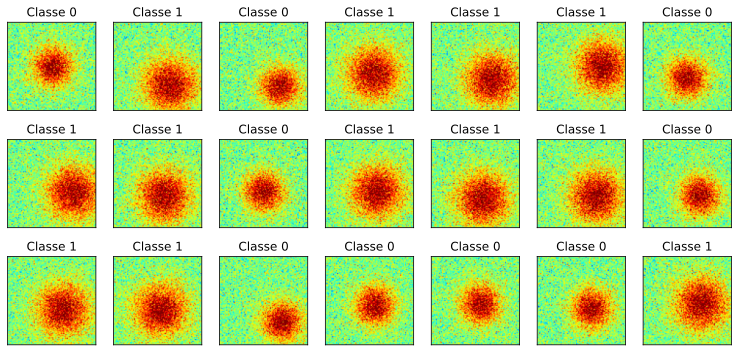

In [4]:
# Visualizando algumas imagens
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax, in enumerate(axs.flatten()):
    whichpic = np.random.randint(2*nPerClass)
    G = np.squeeze(images[whichpic,:,:])
    ax.imshow(G, vmin=-1, vmax=1, cmap='jet')
    ax.set_title('Classe %s'%int(labels[whichpic].item()))
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()